# Winter Arctic sea ice state variability (updates through to April 2022)

**Summary**: In this notebook, we provide updates to the original winter Arctic sea ice thickness notebooks with an additional winter (2021-2022) of data collection. Here we read the IS2SITMOGR4 files from our AWS S3 bucket, instead of our aggregated Jupyter Book dataset. I generally focus on showing the ''smoothed/interpolated' variables, whereas Petty et al., (2023) focussed more on the non-interpolated gridded data. Once we produce an updated aggregated Jupyter Book dataset we can update this notebook with those additional variables. 

**Version history**: Version 1 (01/23/2023)
 

# Import notebook dependencies

In [1]:
# For working with gridded climate data 
import xarray as xr 
# Helper function for reading the data from the bucket
from utils.read_data_utils import read_IS2SITMOGR4 
from utils.plotting_utils import static_winter_comparison_lineplot, staticArcticMaps, staticArcticMaps_overlayDrifts, interactiveArcticMaps, compute_gridcell_winter_means, interactive_winter_comparison_lineplot # Plotting utils 
import numpy as np
# Plotting dependencies
#%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl
# Sets figure size in the notebook
mpl.rcParams['figure.dpi'] = 150 

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 


In [2]:
# Set some plotting parameters
mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "sans-serif",
    'mathtext.fontset': 'stixsans',
    "lines.linewidth": 1.,
    "font.size": 8,
    #"lines.alpha": 0.8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})
mpl.rcParams['font.sans-serif'] = ['Arial']

In [3]:
# Read in the raw monthly gridded winter Arctic sea ice data from S3 (still using V2)
IS2SITMOGR4_all = read_IS2SITMOGR4(data_type='zarr-s3', 
                                   local_data_path='./data/IS2SITMOGR4/', version='V2',persist=True) 
IS2SITMOGR4_all

load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V3/IS2SITMOGR4_V3_201811-202404.zarr


<xarray.Dataset> Size: 653MB
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 545kB 31.1 31.2 ... 34.47
    longitude                       (y, x) float32 545kB 168.3 168.1 ... -9.999
  * time                            (time) datetime64[ns] 368B 2018-11-01 ......
  * x                               (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                               (y) float32 2kB 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 184B dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density                     (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness                   (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_sm                 (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_w99                (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 25MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V3 dataset.
    history:      Created 28/11/23
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...

In [4]:
# Years over which to perform analysis
years = [2018,2019,2020, 2021]

# Winter mean Arctic maps (static)
Compute and map (static) mean winter sea ice conditions across the years of analysis chosen

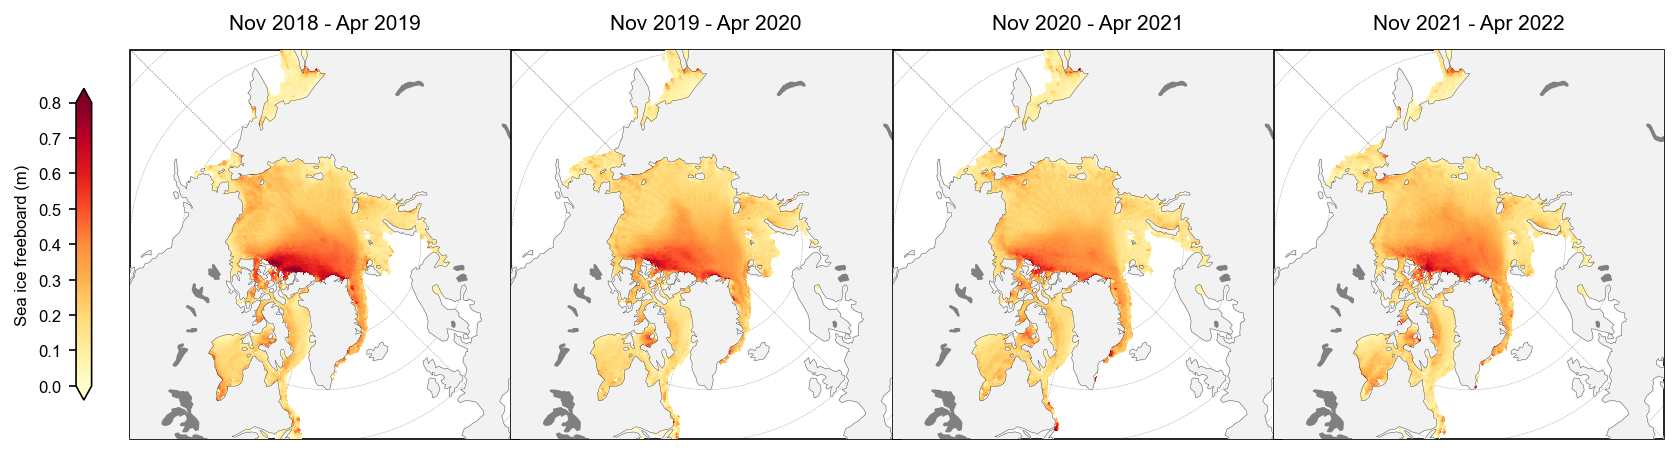

In [5]:
freeboard_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.freeboard_int, years=years)
staticArcticMaps(freeboard_winter_means, dates=freeboard_winter_means.time.values, set_cbarlabel = "Sea ice freeboard (m)", cmap="YlOrRd", col_wrap=4, vmin=0, vmax=0.8, out_str='freeboard_winter_2018_2022')


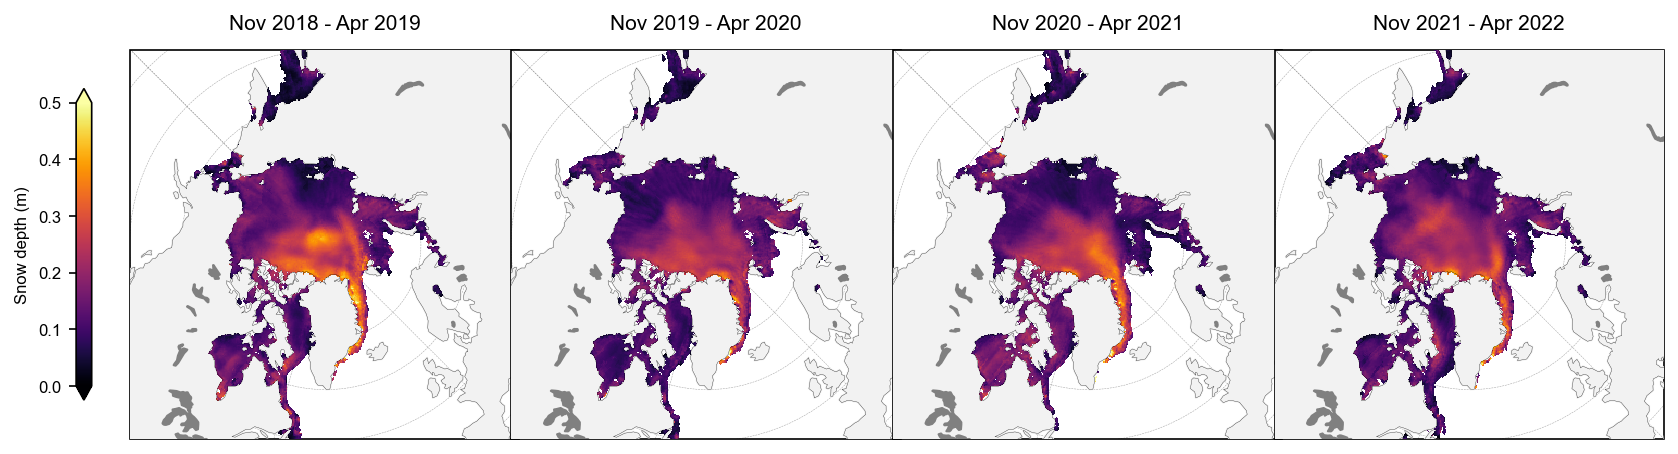

In [6]:
snow_depth_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.snow_depth_int, years=years)
staticArcticMaps(snow_depth_winter_means, dates=snow_depth_winter_means.time.values,set_cbarlabel = "Snow depth (m)", cmap="inferno", col_wrap=4, vmin=0, vmax=0.5, out_str='snowdepth_winter_2018_2022')


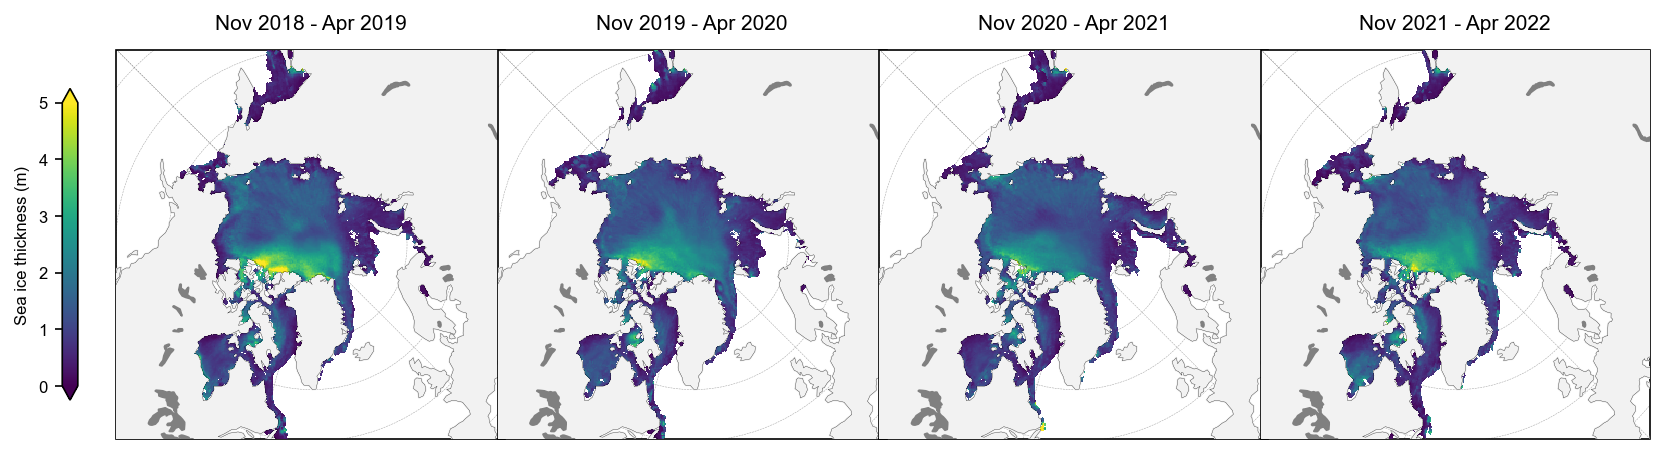

In [7]:
thickness_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.ice_thickness_int, years=years)
staticArcticMaps(thickness_winter_means, dates=thickness_winter_means.time.values,title="", set_cbarlabel = "Sea ice thickness (m)", col_wrap=4, cmap="viridis", vmin=0, vmax=5, out_str='thickness_winter_2018_2022')


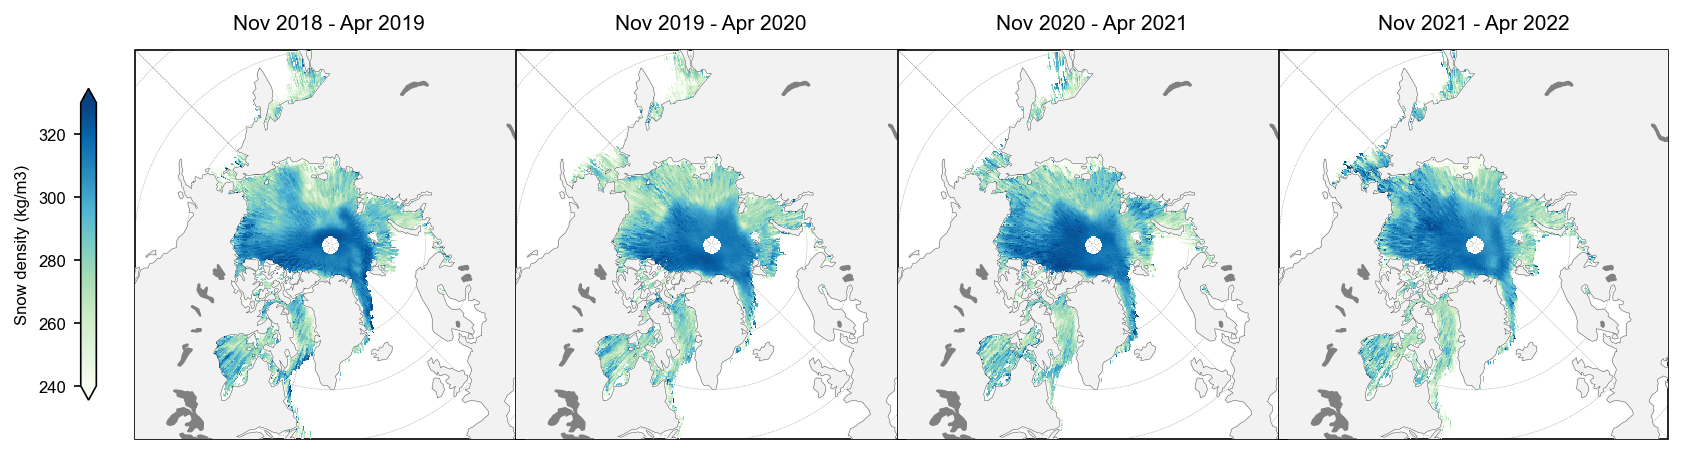

In [8]:
snow_density_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.snow_density, years=years)
staticArcticMaps(snow_density_winter_means, dates=snow_density_winter_means.time.values,set_cbarlabel = "Snow density (kg/m3)", cmap="GnBu", col_wrap=4, vmin=240, vmax=330, out_str='snowdensity_winter_2018_2022')


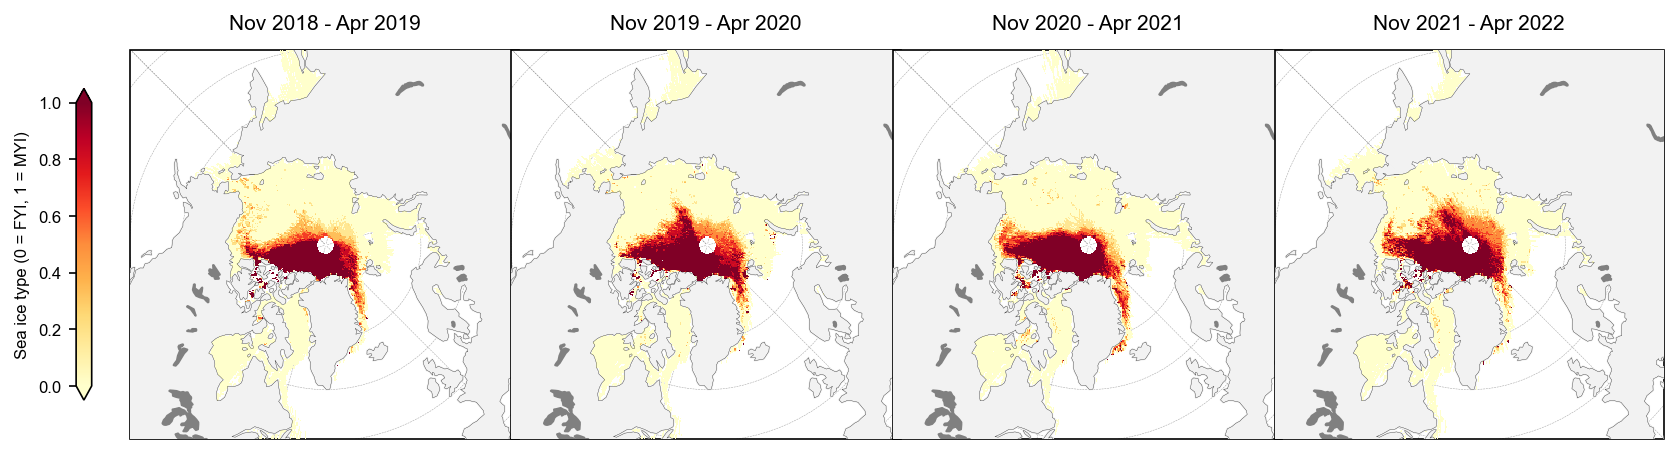

In [9]:
ice_type_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.ice_type, years=years)
staticArcticMaps(ice_type_winter_means, dates=ice_type_winter_means.time.values, set_cbarlabel = "Sea ice type (0 = FYI, 1 = MYI)", col_wrap=4, cmap="YlOrRd", vmin=0, vmax=1, out_str='icetype_winter_2018_2022')


# Winter anomaly plots
Compute and map (static) winter anomaly maps (relative to the mean across the three winters by default) for given variables across the four winters

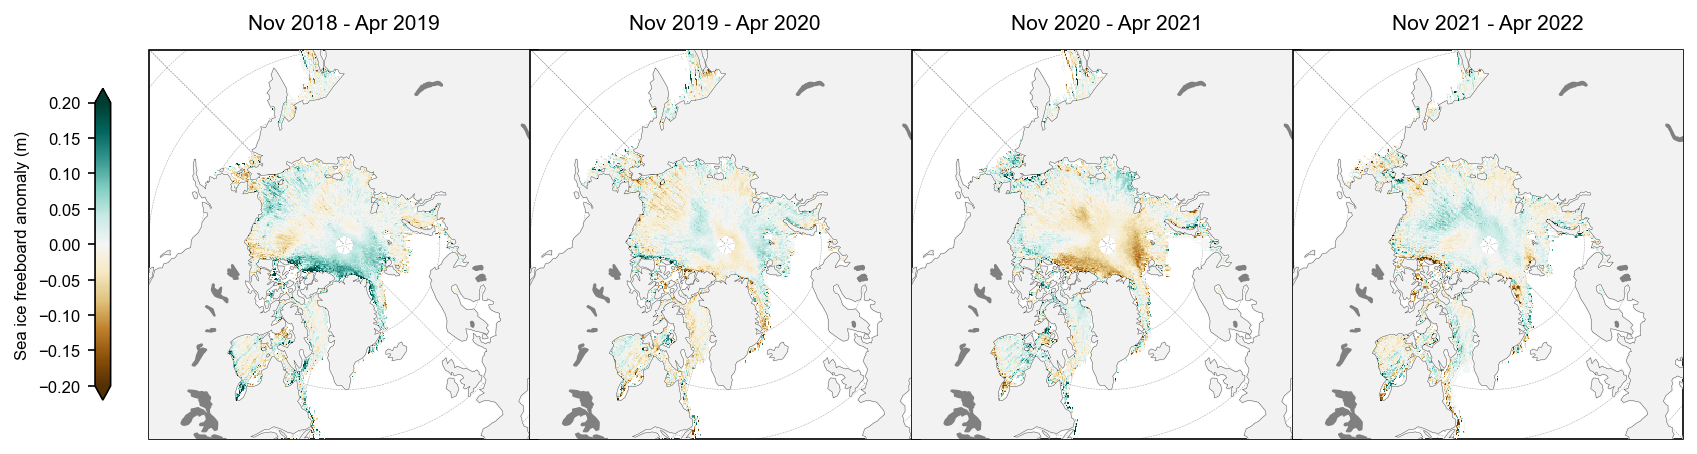

In [10]:
freeboard_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.freeboard, years=years)
staticArcticMaps(freeboard_winter_means-freeboard_winter_means.mean(axis=0), dates=freeboard_winter_means.time.values,title="", col_wrap=4, set_cbarlabel = "Sea ice freeboard anomaly (m)", cmap="BrBG", vmin=-0.2, vmax=0.2, out_str='freeboard_winter_anomaly_2018_2022')


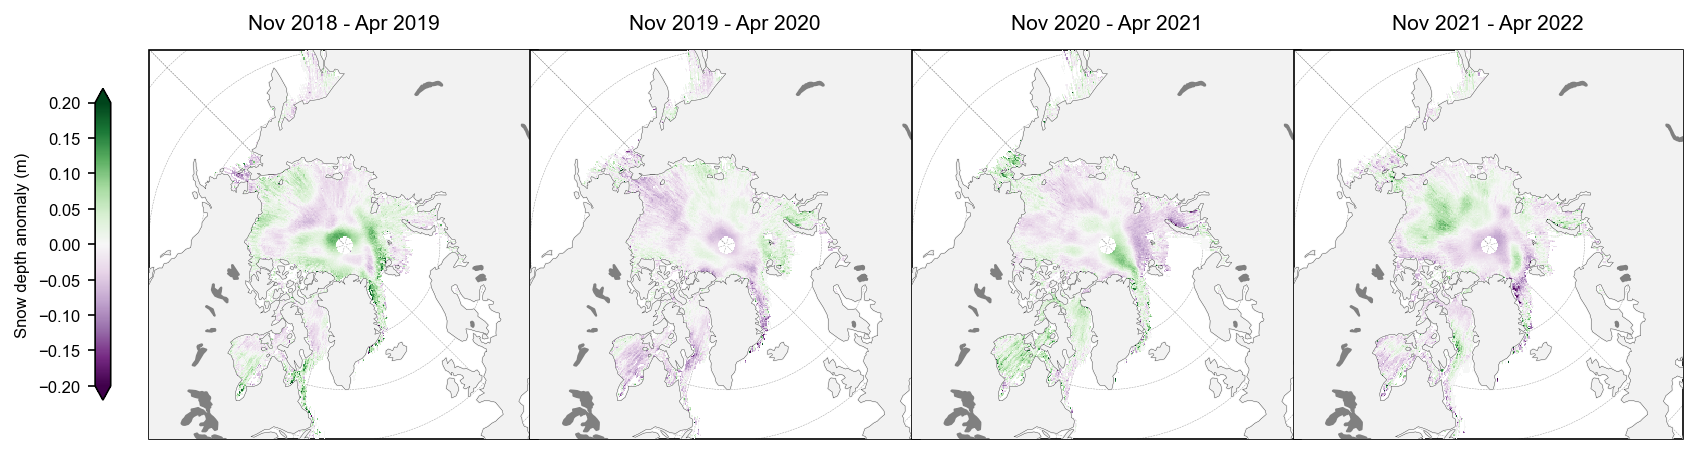

In [11]:
snow_depth_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.snow_depth, years=years)
staticArcticMaps(snow_depth_winter_means-snow_depth_winter_means.mean(axis=0), dates=snow_depth_winter_means.time.values,col_wrap=4, set_cbarlabel = "Snow depth anomaly (m)", cmap="PRGn", vmin=-0.2, vmax=0.2, out_str='snowdepth_winter_anomaly_2018_2022')


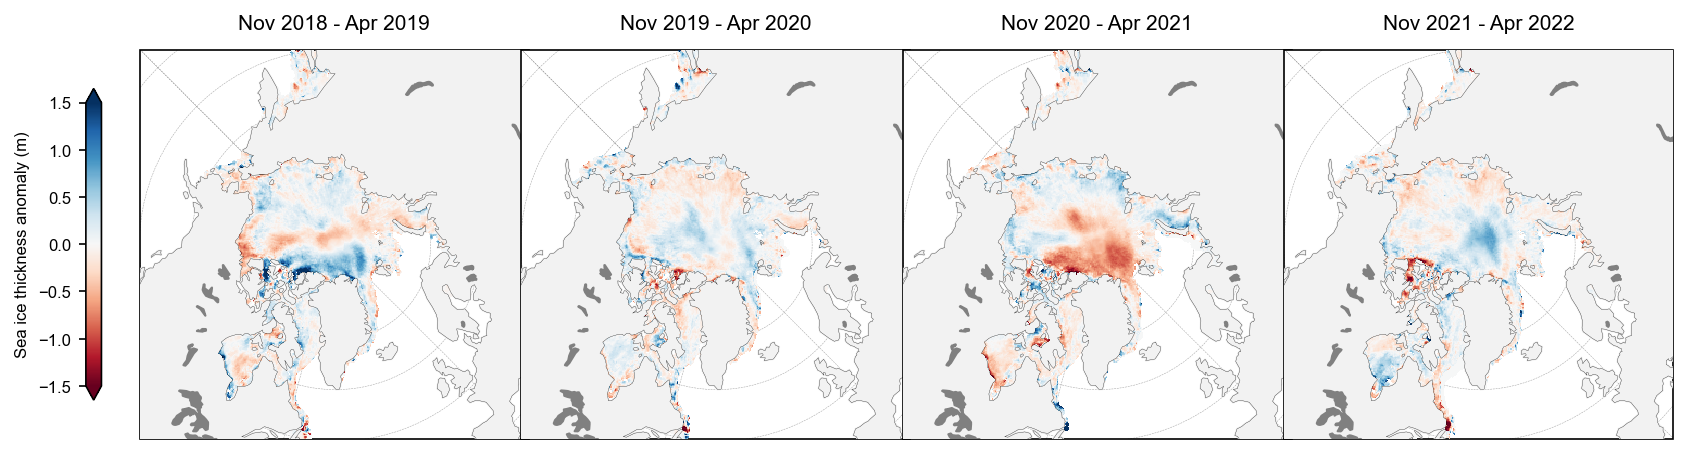

In [12]:
thickness_winter_means = compute_gridcell_winter_means(IS2SITMOGR4_all.ice_thickness_int, years=years)
staticArcticMaps(thickness_winter_means-thickness_winter_means.mean(axis=0), dates=thickness_winter_means.time.values,col_wrap=4, set_cbarlabel = "Sea ice thickness anomaly (m)", cmap="RdBu", vmin=-1.5, vmax=1.5, out_str='thickness_winter_anomaly_2018_2022')


# Monthly mean timeseries 
Next we'll compute monthly means by averaging over all gridcells within a given region. We'll use this to generate a lineplot to compare across the three winter seasons for each variable.

In [13]:
# Here is where we might also want to set a region mask, e.g. to avoid including some of the more uncertain data in the peripheral seas
innerArctic = [1,2,3,4,5]
IS2SITMOGR4_all_innerArctic = IS2SITMOGR4_all.where(IS2SITMOGR4_all.region_mask.isin(innerArctic))

# Uncomment out to set an additional ice type mask too and change the save_label accordingly (0 = FYI, 1 = MYI)
#IS2SITMOGR4_all_innerArctic = IS2SITMOGR4_all_innerArctic.where(IS2SITMOGR4_all_innerArctic.ice_type==1)

save_label='Inner_Arctic'


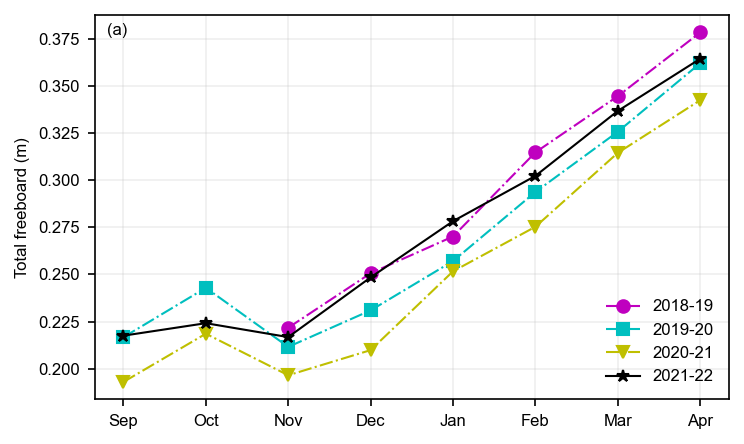

In [14]:
static_winter_comparison_lineplot(IS2SITMOGR4_all_innerArctic.freeboard, years=years, start_month="Sep", figsize=(5,3), annotation='(a)', set_ylabel=r'Total freeboard (m)', save_label=save_label, loc_pos=4, legend=True)

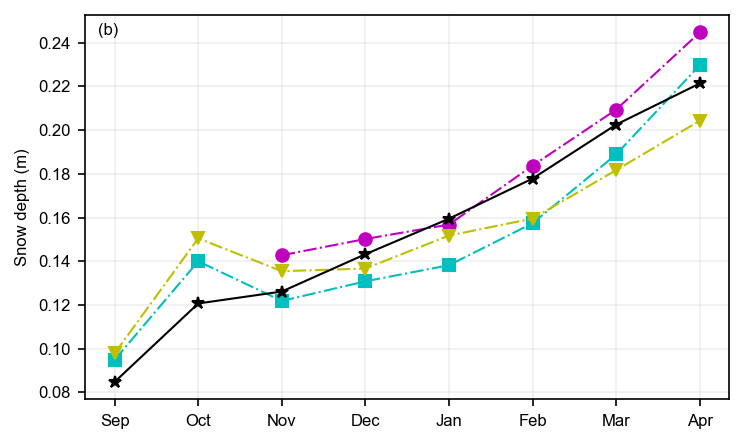

In [15]:
static_winter_comparison_lineplot(IS2SITMOGR4_all_innerArctic.snow_depth, years=years, start_month="Sep", figsize=(5,3), annotation='(b)',set_ylabel='Snow depth (m)', save_label=save_label, legend=False)

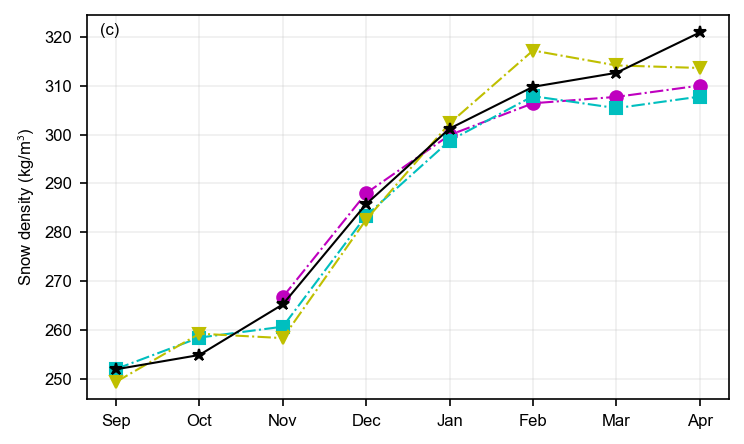

In [16]:
static_winter_comparison_lineplot(IS2SITMOGR4_all_innerArctic.snow_density, years=years, start_month="Sep", figsize=(5,3), annotation='(c)',set_ylabel=r'Snow density (kg/m$^3$)', save_label=save_label, legend=False)

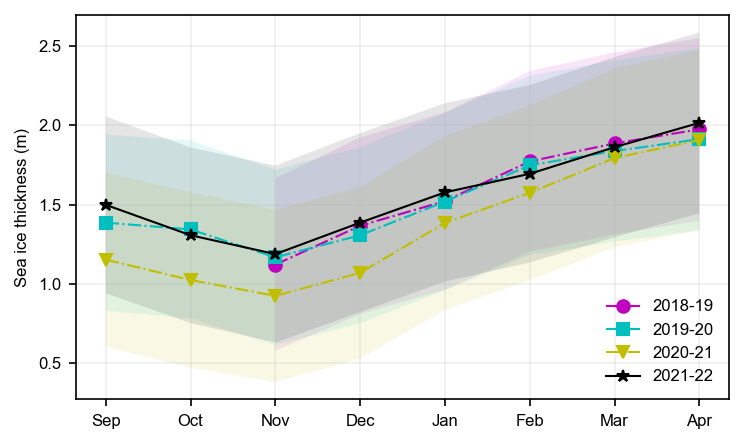

In [17]:
static_winter_comparison_lineplot(IS2SITMOGR4_all_innerArctic.ice_thickness, 
                                  da_unc = IS2SITMOGR4_all_innerArctic.ice_thickness_unc, 
                                  years=years, start_month="Sep", figsize=(5,3), set_ylabel='Sea ice thickness (m)', save_label=save_label, annotation='', legend=True)

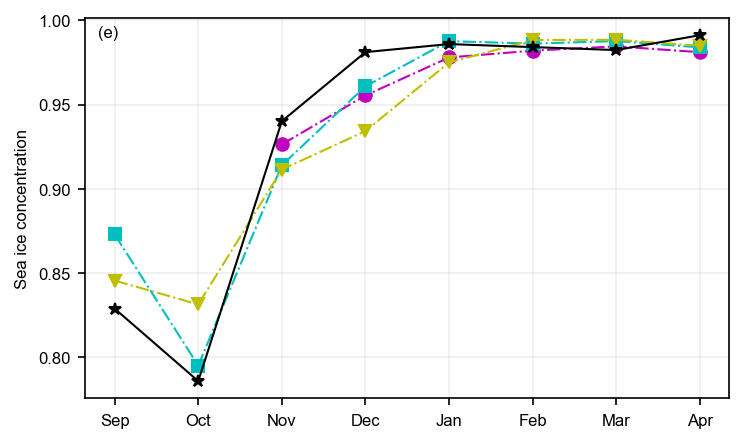

In [18]:
static_winter_comparison_lineplot(IS2SITMOGR4_all_innerArctic.sea_ice_conc, years=years, start_month="Sep", figsize=(5,3), annotation='(e)', set_ylabel='Sea ice concentration', save_label=save_label, legend=False)

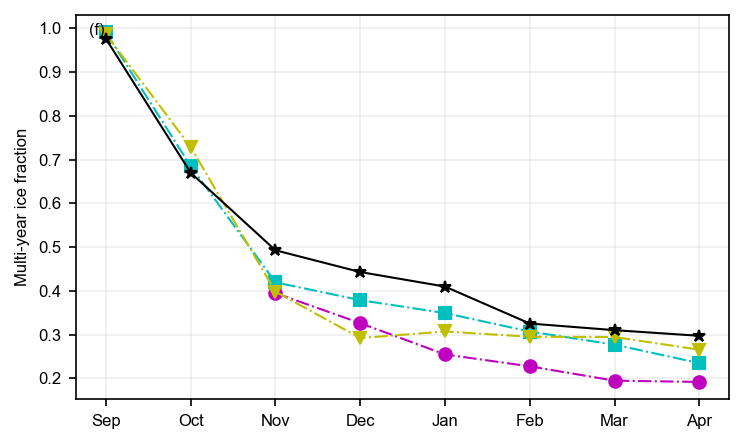

In [22]:
static_winter_comparison_lineplot(IS2SITMOGR4_all_innerArctic.ice_type, years=years, start_month="Sep", figsize=(5,3), annotation='(f)',set_ylabel='Multi-year ice fraction', save_label=save_label, legend=False)